# 001 - Exploratory Data Analysis: SpatialMQA Benchmark
### *Can Multimodal Large Language Models Understand Spatial Relations?* (ACL 2025)

**Paper Authors:** Jingping Liu, Ziyan Liu, Zhedong Cen, Yan Zhou, Yinan Zou, Weiyan Zhang, Haiyun Jiang, Tong Ruan  
**Affiliations:** East China University of Science and Technology & Fudan University  
**Conference:** ACL 2025 (Long Papers, Vienna, Austria)  
**Dataset Repository:** [Hugging Face: liuziyan/SpatialMQA](https://huggingface.co/datasets/liuziyan/SpatialMQA) | [GitHub: ziyan-xiaoyu/SpatialMQA](https://github.com/ziyan-xiaoyu/SpatialMQA)

---

### Objectives of this Notebook:
1. **Explore Data Splits & Scale:** Understand the distribution of 5,392 human-annotated samples across `train`, `dev`, `test`, and `invisible` subsets.
2. **Analyze 3D Spatial Relations:** Evaluate the 6 canonical relations across 3 spatial axes (X: Horizontal, Y: Depth, Z: Vertical).
3. **Deconstruct Perspective Shifts:** Classify questions into Out-of-Image (Q1), First-Person (Q2), and Third-Person (Q3).
4. **Candidate Options & Guessing Baseline:** Analyze choice set sizes (2, 4, 6 options) and theoretical random chance.
5. **Invisible / Non-BBox Entities:** Examine the 811 samples that lack bounding box constraints.
6. **Visual Inspection:** Render multimodal examples pairing COCO images with spatial queries.


In [1]:
import os
import json
import re
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# Aesthetic plotting style
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

# Robust Data Directory Resolution
DATA_DIR = 'data/spatial_mqa' if os.path.exists('data/spatial_mqa') else '../data/spatial_mqa'
IMAGES_DIR = os.path.join(DATA_DIR, 'images')

print(f"Data directory: {os.path.abspath(DATA_DIR)}")
print(f"Available files: {os.listdir(DATA_DIR)}")


Data directory: /home/phuckhang/MyWorkspace/Spatial-Temporal-KG/data/spatial_mqa
Available files: ['train.jsonl', 'images', 'types.txt', 'test.jsonl', 'dev.jsonl', 'invisible.jsonl']


---
## 1. Data Ingestion & Split Overview

SpatialMQA contains **5,392** samples collected from COCO2017, divided into `train` (70%), `dev` (10%), and `test` (20%).  
Additionally, the authors provided `invisible.jsonl` containing 811 questions involving invisible/non-bounding-box entities, and `types.txt` defining 128 subject/object categories.


In [2]:
def load_jsonl(filename):
    filepath = os.path.join(DATA_DIR, filename)
    records = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for idx, line in enumerate(f):
            data = json.loads(line.strip())
            data['sample_id'] = f"{filename.split('.')[0]}_{idx}"
            data['split'] = filename.split('.')[0]
            records.append(data)
    return pd.DataFrame(records)

df_train = load_jsonl('train.jsonl')
df_dev = load_jsonl('dev.jsonl')
df_test = load_jsonl('test.jsonl')
df_invisible = load_jsonl('invisible.jsonl')

df_all = pd.concat([df_train, df_dev, df_test], ignore_index=True)

print(f"Train samples: {len(df_train):,}")
print(f"Dev samples:   {len(df_dev):,}")
print(f"Test samples:  {len(df_test):,}")
print(f"Total benchmark samples: {len(df_all):,}")
print(f"Invisible subset samples: {len(df_invisible):,}")

# Inspect first few samples
df_all[['image', 'question', 'options', 'answer', 'split']].head(4)


Train samples: 3,780
Dev samples:   536
Test samples:  1,076
Total benchmark samples: 5,392
Invisible subset samples: 811


,image,question,options,answer,split
0,000000115857.jpg,"For the clock in the picture, does the minute ...","[left of, right of]",right of,train
1,000000009970.jpg,"If you were the giraffe in the picture, would ...","[left of, right of]",left of,train
2,000000088939.jpg,If you are the largest elephant in the picture...,"[in front of, behind, left of, right of]",right of,train
3,000000055345.jpg,"If you were the little girl in the picture, wh...","[in front of, behind, left of, right of]",left of,train


In [3]:
split_summary = pd.DataFrame({
    'Split': ['Train', 'Dev', 'Test', 'Total Benchmark', 'Invisible Subset'],
    'Sample Count': [len(df_train), len(df_dev), len(df_test), len(df_all), len(df_invisible)],
    'Percentage (%)': [
        len(df_train)/len(df_all)*100,
        len(df_dev)/len(df_all)*100,
        len(df_test)/len(df_all)*100,
        100.0,
        len(df_invisible)/len(df_all)*100
    ],
    'Unique Images': [
        df_train['image'].nunique(),
        df_dev['image'].nunique(),
        df_test['image'].nunique(),
        df_all['image'].nunique(),
        df_invisible['image'].nunique()
    ],
    'Avg Questions / Image': [
        len(df_train) / df_train['image'].nunique(),
        len(df_dev) / df_dev['image'].nunique(),
        len(df_test) / df_test['image'].nunique(),
        len(df_all) / df_all['image'].nunique(),
        len(df_invisible) / df_invisible['image'].nunique()
    ]
})

split_summary.round(2)


,Split,Sample Count,Percentage (%),Unique Images,Avg Questions / Image
0,Train,3780,70.10,3603,1.05
1,Dev,536,9.94,532,1.01
2,Test,1076,19.96,1066,1.01
3,Total Benchmark,5392,100.00,5063,1.06
4,Invisible Subset,811,15.04,806,1.01


---
## 2. Spatial Relations & 3D Spatial Coordinate System (SCS)

The paper formalizes spatial reasoning into a 3D Spatial Coordinate System established in the objective world:
- **X-axis (Horizontal):** `left of` ($x_s < x_o$) vs `right of` ($x_s > x_o$)
- **Y-axis (Depth/Egocentric):** `in front of` vs `behind`
- **Z-axis (Vertical):** `on/above` ($z_s > z_o$) vs `below` ($z_s < z_o$)

Let's verify the distribution across all 6 relations and test for directional symmetry.


/tmp/ipykernel_64493/3134540956.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rel_counts.index, y=rel_counts.values, ax=axes[0], palette=colors)


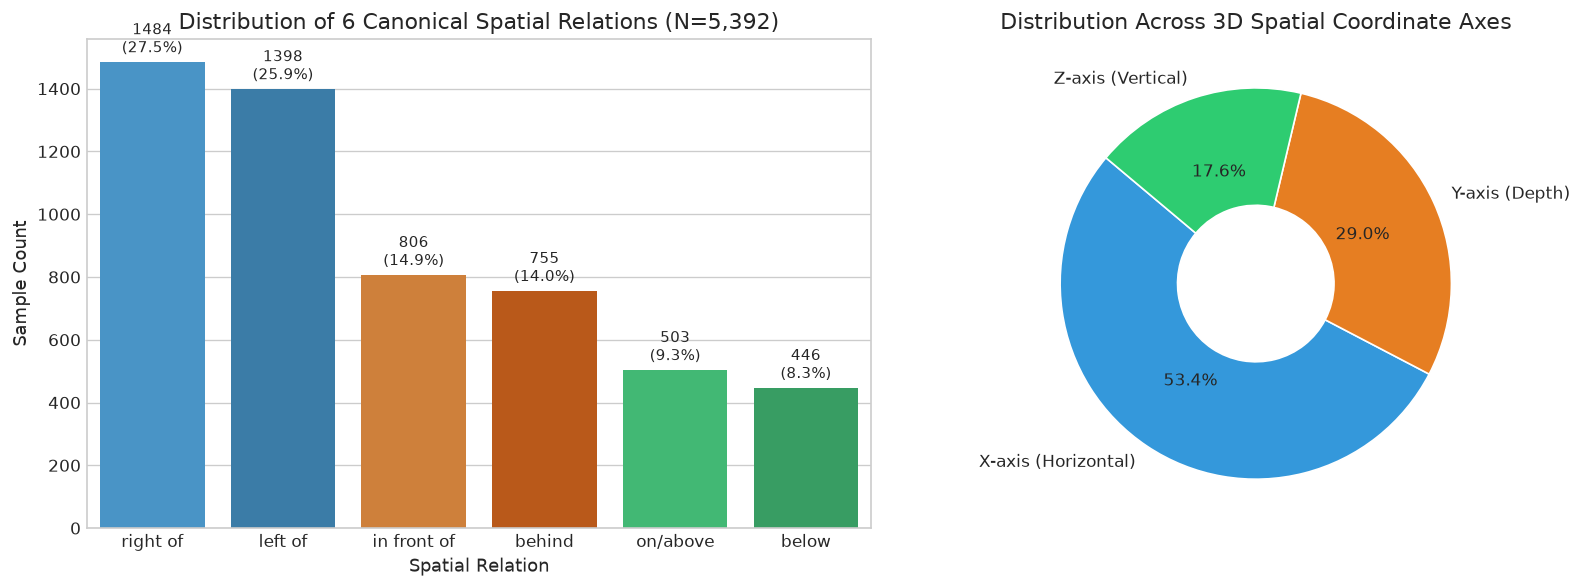

In [4]:
# Define Axis Mapping
AXIS_MAP = {
    'left of': 'X-axis (Horizontal)',
    'right of': 'X-axis (Horizontal)',
    'in front of': 'Y-axis (Depth)',
    'behind': 'Y-axis (Depth)',
    'on/above': 'Z-axis (Vertical)',
    'below': 'Z-axis (Vertical)'
}

df_all['axis'] = df_all['answer'].map(AXIS_MAP)
df_train['axis'] = df_train['answer'].map(AXIS_MAP)
df_dev['axis'] = df_dev['answer'].map(AXIS_MAP)
df_test['axis'] = df_test['answer'].map(AXIS_MAP)

# Plot overall relation distribution and axis distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Six Relations Bar Plot
rel_counts = df_all['answer'].value_counts()
colors = ['#3498db', '#2980b9', '#e67e22', '#d35400', '#2ecc71', '#27ae60']
sns.barplot(x=rel_counts.index, y=rel_counts.values, ax=axes[0], palette=colors)
axes[0].set_title('Distribution of 6 Canonical Spatial Relations (N=5,392)')
axes[0].set_ylabel('Sample Count')
axes[0].set_xlabel('Spatial Relation')
for p in axes[0].patches:
    axes[0].annotate(f"{int(p.get_height())}\n({p.get_height()/len(df_all)*100:.1f}%)",
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=9, xytext=(0, 3),
                    textcoords='offset points')

# 2. 3D Spatial Axes Pie Chart
axis_counts = df_all['axis'].value_counts()
axes[1].pie(axis_counts.values, labels=axis_counts.index, autopct='%1.1f%%',
           startangle=140, colors=['#3498db', '#e67e22', '#2ecc71'],
           wedgeprops=dict(width=0.6, edgecolor='w'))
axes[1].set_title('Distribution Across 3D Spatial Coordinate Axes')

plt.tight_layout()
plt.show()


In [5]:
# Compare relation percentages across splits
rel_split = pd.crosstab(df_all['answer'], df_all['split'], normalize='columns') * 100
rel_split = rel_split[['train', 'dev', 'test']]
rel_split['Overall (%)'] = (df_all['answer'].value_counts(normalize=True) * 100)
rel_split['Paper Table 3 (%)'] = [14.00, 8.27, 14.95, 25.93, 9.33, 27.52]

print("=== Spatial Relation Percentage by Split vs Paper Table 3 ===")
display(rel_split.round(2))

# Directional Symmetry Check
print("\n=== Directional Symmetry Check ===")
sym_pairs = [('left of', 'right of', 'X-axis'), ('in front of', 'behind', 'Y-axis'), ('on/above', 'below', 'Z-axis')]
for r1, r2, ax_name in sym_pairs:
    c1, c2 = len(df_all[df_all['answer'] == r1]), len(df_all[df_all['answer'] == r2])
    print(f"{ax_name:20s}: {r1:12s} = {c1:4d} ({c1/len(df_all)*100:.1f}%)  vs  {r2:12s} = {c2:4d} ({c2/len(df_all)*100:.1f}%)  [Delta: {abs(c1-c2)}]")


=== Spatial Relation Percentage by Split vs Paper Table 3 ===


split,train,dev,test,Overall (%),Paper Table 3 (%)
answer,,,,,
behind,13.99,13.99,14.03,14.00,14.00
below,8.28,8.21,8.27,8.27,8.27
in front of,14.95,14.93,14.96,14.95,14.95
left of,25.93,25.93,25.93,25.93,25.93
on/above,9.34,9.33,9.29,9.33,9.33
right of,27.51,27.61,27.51,27.52,27.52



=== Directional Symmetry Check ===
X-axis              : left of      = 1398 (25.9%)  vs  right of     = 1484 (27.5%)  [Delta: 86]
Y-axis              : in front of  =  806 (14.9%)  vs  behind       =  755 (14.0%)  [Delta: 51]
Z-axis              : on/above     =  503 (9.3%)  vs  below        =  446 (8.3%)  [Delta: 57]


---
## 3. Perspective Shifts & Question Types

One of SpatialMQA's primary breakthroughs is formalizing **observer perspectives**:
1. **Rule 1 / Q1 (Out-of-image):** Observer is outside the image (e.g. *"Where is the fork located relative to the pizza?"*).
2. **Rule 2 / Q2 (In-image First-person):** Observer is the object entity in the image (e.g. *"If you are the cyclist in the image, where is the dog located relative to you?"*).
3. **Rule 3 / Q3 (In-image Third-person):** Observer is a 3rd distinct living entity inside the scene (e.g. *"If you are the driver of the bus in the image, from your perspective, where is the red car located relative to the bus?"*).


=== Perspective Counts (Exact Match with Paper Table 3) ===


split,train,dev,test,All
perspective,,,,
Q1_OutOfImage,1514,217,452,2183
Q2_FirstPerson,2137,301,590,3028
Q3_ThirdPerson,129,18,34,181
All,3780,536,1076,5392



=== Perspective Percentages (%) ===


split,train,dev,test
perspective,,,
Q1_OutOfImage,40.05,40.49,42.01
Q2_FirstPerson,56.53,56.16,54.83
Q3_ThirdPerson,3.41,3.36,3.16


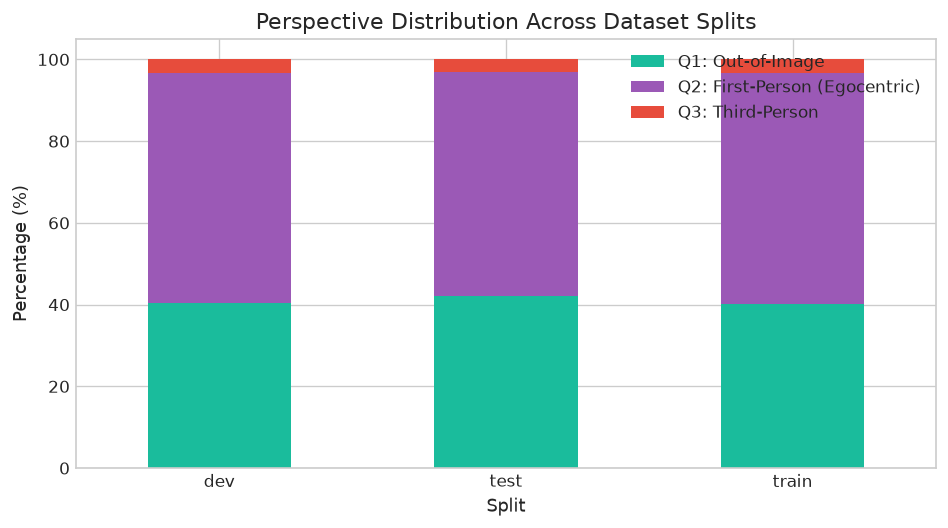

In [6]:
def classify_perspective(q):
    ql = q.lower()
    if 'from your perspective' in ql or 'from the perspective' in ql:
        return 'Q3_ThirdPerson'
    elif 'if you' in ql:
        return 'Q2_FirstPerson'
    else:
        return 'Q1_OutOfImage'

df_all['perspective'] = df_all['question'].apply(classify_perspective)
df_train['perspective'] = df_train['question'].apply(classify_perspective)
df_dev['perspective'] = df_dev['question'].apply(classify_perspective)
df_test['perspective'] = df_test['question'].apply(classify_perspective)

persp_summary = pd.crosstab(df_all['perspective'], df_all['split'], margins=True)
persp_summary = persp_summary[['train', 'dev', 'test', 'All']]
persp_pct = pd.crosstab(df_all['perspective'], df_all['split'], normalize='columns') * 100

print("=== Perspective Counts (Exact Match with Paper Table 3) ===")
display(persp_summary)

print("\n=== Perspective Percentages (%) ===")
display(persp_pct[['train', 'dev', 'test']].round(2))

# Plot Perspective Distribution
fig, ax = plt.subplots(figsize=(8, 4.5))
persp_order = ['Q1_OutOfImage', 'Q2_FirstPerson', 'Q3_ThirdPerson']
persp_plot_data = pd.crosstab(df_all['split'], df_all['perspective'], normalize='index') * 100
persp_plot_data[persp_order].plot(kind='bar', stacked=True, ax=ax, color=['#1abc9c', '#9b59b6', '#e74c3c'])
ax.set_title('Perspective Distribution Across Dataset Splits')
ax.set_ylabel('Percentage (%)')
ax.set_xlabel('Split')
ax.legend(['Q1: Out-of-Image', 'Q2: First-Person (Egocentric)', 'Q3: Third-Person'], loc='upper right')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


=== Question Length Statistics by Perspective ===


,count,min,max,mean,median,std
perspective,,,,,,
Q1_OutOfImage,2183,6,33,15.80,12.0,6.42
Q2_FirstPerson,3028,12,34,20.59,20.0,3.27
Q3_ThirdPerson,181,20,34,25.85,25.0,2.79


/tmp/ipykernel_64493/4027609452.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_all, x='perspective', y='word_count', ax=axes[0], palette='Set2')


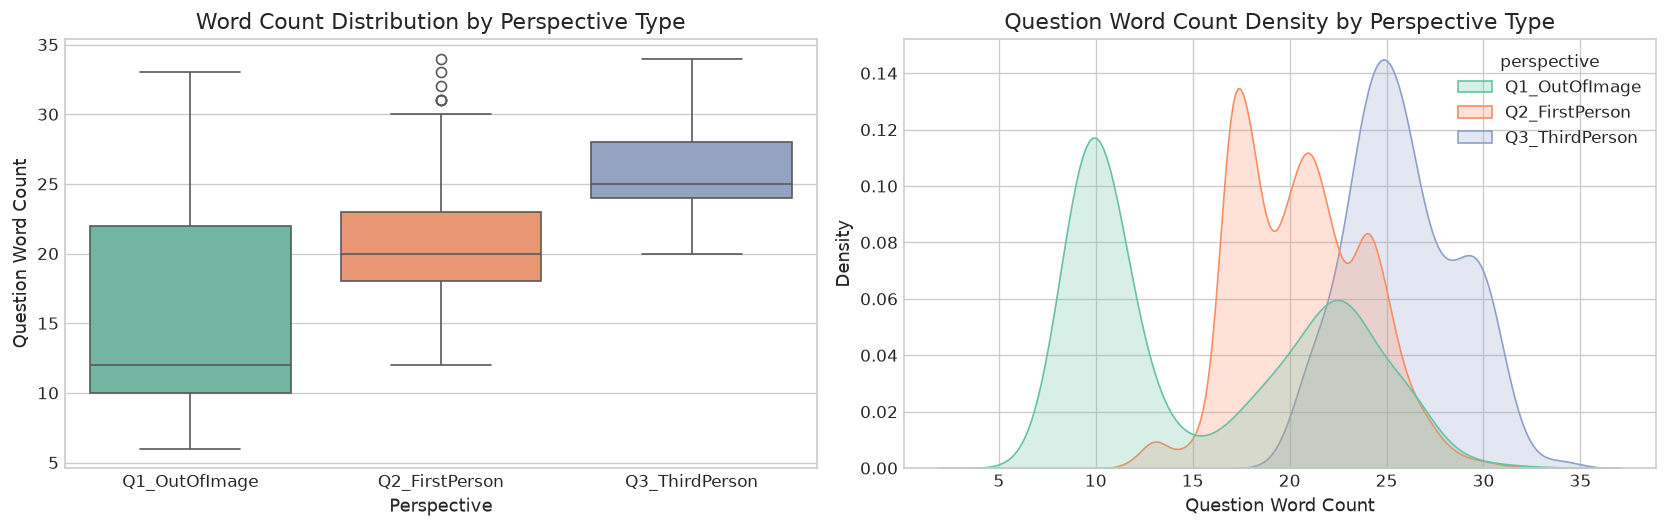

In [7]:
df_all['word_count'] = df_all['question'].apply(lambda x: len(x.split()))
df_all['char_count'] = df_all['question'].apply(lambda x: len(x))

print("=== Question Length Statistics by Perspective ===")
len_stats = df_all.groupby('perspective')['word_count'].agg(['count', 'min', 'max', 'mean', 'median', 'std'])
display(len_stats.round(2))

# Plot word count distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

sns.boxplot(data=df_all, x='perspective', y='word_count', ax=axes[0], palette='Set2')
axes[0].set_title('Word Count Distribution by Perspective Type')
axes[0].set_xlabel('Perspective')
axes[0].set_ylabel('Question Word Count')

sns.kdeplot(data=df_all, x='word_count', hue='perspective', fill=True, common_norm=False, ax=axes[1], palette='Set2')
axes[1].set_title('Question Word Count Density by Perspective Type')
axes[1].set_xlabel('Question Word Count')

plt.tight_layout()
plt.show()


---
## 4. Candidate Options & Random Baseline Analysis

In SpatialMQA, questions are multiple-choice with $k \in \{2, 4, 6\}$ options.
- 4 options is the most prevalent format (74.8%), covering the planar horizontal and depth relations (`left of, right of, in front of, behind`).
- 6 options covers the entire 3D space (`left/right, front/behind, on-above/below`).
- 2 options restricts reasoning to a single axis (e.g. `left of` vs `right of`).

Let's compute the theoretical random guessing accuracy:
$$\mathbb{E}[\text{Random Accuracy}] = \sum_{k \in \{2, 4, 6\}} P(K=k) \times \frac{1}{k}$$


In [8]:
df_all['num_options'] = df_all['options'].apply(len)
opt_counts = df_all['num_options'].value_counts().sort_index()

opt_df = pd.DataFrame({
    'Num Options': opt_counts.index,
    'Sample Count': opt_counts.values,
    'Percentage (%)': (opt_counts.values / len(df_all) * 100).round(2),
    'Random Chance (1/k)': [f"{1/k*100:.1f}%" for k in opt_counts.index]
})

display(opt_df)

# Calculate Theoretical Random Guessing Accuracy
random_acc = sum((count / len(df_all)) * (1 / k) for k, count in opt_counts.items()) * 100
print(f"Theoretical Random Guessing Accuracy: {random_acc:.2f}%")
print(f"Paper Reported Random Selection Accuracy: 28.50%")

# Most Common Option Combinations
df_all['options_tuple'] = df_all['options'].apply(lambda x: tuple(sorted(x)))
top_option_sets = df_all['options_tuple'].value_counts().head(5)
print("\nTop Option Sets:")
for opts, cnt in top_option_sets.items():
    print(f"  Count: {cnt:4d} ({cnt/len(df_all)*100:5.1f}%) | Options: {list(opts)}")


,Num Options,Sample Count,Percentage (%),Random Chance (1/k)
0,2,637,11.81,50.0%
1,4,4035,74.83,25.0%
2,6,720,13.35,16.7%


Theoretical Random Guessing Accuracy: 26.84%
Paper Reported Random Selection Accuracy: 28.50%

Top Option Sets:
  Count: 3326 ( 61.7%) | Options: ['behind', 'in front of', 'left of', 'right of']
  Count:  720 ( 13.4%) | Options: ['behind', 'below', 'in front of', 'left of', 'on/above', 'right of']
  Count:  703 ( 13.0%) | Options: ['below', 'left of', 'on/above', 'right of']
  Count:  475 (  8.8%) | Options: ['left of', 'right of']
  Count:  158 (  2.9%) | Options: ['below', 'on/above']


---
## 5. Non-Bounding Box & Invisible Entities Analysis

Prior benchmarks (SpatialVOC2K, Rel3D, SpatialSense) relied on explicit bounding boxes framing the subject and object. SpatialMQA avoids this constraint, which enables:
1. Grounding unseen or unframeable entities (e.g., `sun`, `wind`, `sound`, `sky`).
2. Egocentric reasoning where the observer is an embodied agent whose coordinate system is derived implicitly.
3. Realistic scenes where target objects may be partially occluded or implied.


In [9]:
print(f"Total invisible samples: {len(df_invisible)} ({len(df_invisible)/len(df_all)*100:.1f}% of benchmark)")

# Check relations in invisible subset
invis_rels = df_invisible['answer'].value_counts()
print("\nInvisible Subset Spatial Relations:")
for r, c in invis_rels.items():
    print(f"  {r:12s}: {c:4d} ({c/len(df_invisible)*100:.1f}%)")

# Inspect sample invisible questions
print("\nSample Questions with Invisible / Non-BBox Entities:")
for idx, row in df_invisible.head(5).iterrows():
    print(f"  [{row['answer']:11s}] {row['question']}")


Total invisible samples: 811 (15.0% of benchmark)

Invisible Subset Spatial Relations:
  right of    :  284 (35.0%)
  left of     :  243 (30.0%)
  in front of :  144 (17.8%)
  behind      :  140 (17.3%)

Sample Questions with Invisible / Non-BBox Entities:
  [in front of] If you were sitting on the motorcycle in the image about to start, where would the cat be located relative to you?
  [left of    ] If you were lying flat on the bed in the image with your head on the pillow, on which side of you would the window be?
  [right of   ] If you were the woman in the image, where would the sun be in relation to you?
  [left of    ] If you were lying flat on the bed in the image with your head on a pillow, where would your landline phone be located relative to you?
  [in front of] If you are the person wearing the red top skiing in the image, where is the sun located relative to you?


---
## 6. Entity Types (128 Categories)

The benchmark defines 128 subject and object categories in `types.txt`, expanding upon COCO80 classes.


Total entity categories in types.txt: 128
Sample categories: ['person', 'letter', 'natural scenery', 'hand', 'cat', 'cup', 'sports ball', 'dog', 'car', 'lamp', 'cell phone', 'fork', 'clock', 'bottle', 'shadow']


/tmp/ipykernel_64493/728613562.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(types_names), ax=ax, palette='Blues_r')


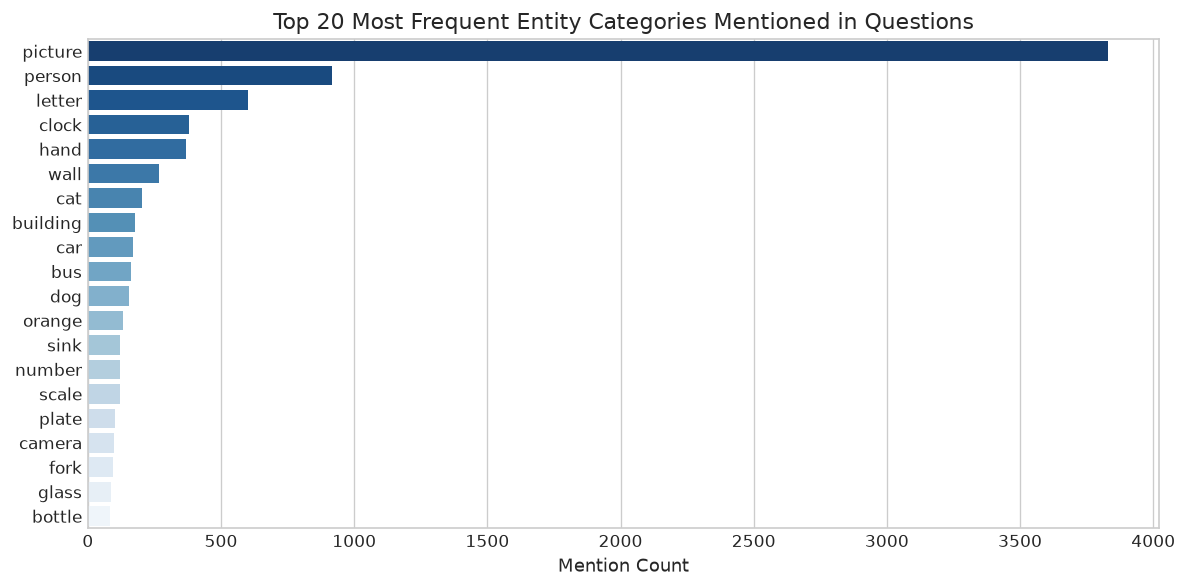

In [10]:
types_path = os.path.join(DATA_DIR, 'types.txt')
with open(types_path, 'r', encoding='utf-8') as f:
    entity_types = [line.strip() for line in f if line.strip()]

print(f"Total entity categories in types.txt: {len(entity_types)}")
print(f"Sample categories: {entity_types[:15]}")

# Entity Frequency in Question Text
def extract_mentioned_types(q):
    ql = q.lower()
    return [t for t in entity_types if re.search(r'\b' + re.escape(t) + r'\b', ql)]

df_all['mentioned_types'] = df_all['question'].apply(extract_mentioned_types)
all_mentions = [t for sublist in df_all['mentioned_types'] for t in sublist]
mention_counts = Counter(all_mentions).most_common(20)

fig, ax = plt.subplots(figsize=(10, 5))
types_names, counts = zip(*mention_counts)
sns.barplot(x=list(counts), y=list(types_names), ax=ax, palette='Blues_r')
ax.set_title('Top 20 Most Frequent Entity Categories Mentioned in Questions')
ax.set_xlabel('Mention Count')
plt.tight_layout()
plt.show()


---
## 7. Multimodal Qualitative Inspection

Let's render representative sample questions alongside their COCO2017 images to visually inspect the spatial reasoning task.


Locally available images for inspection: 25


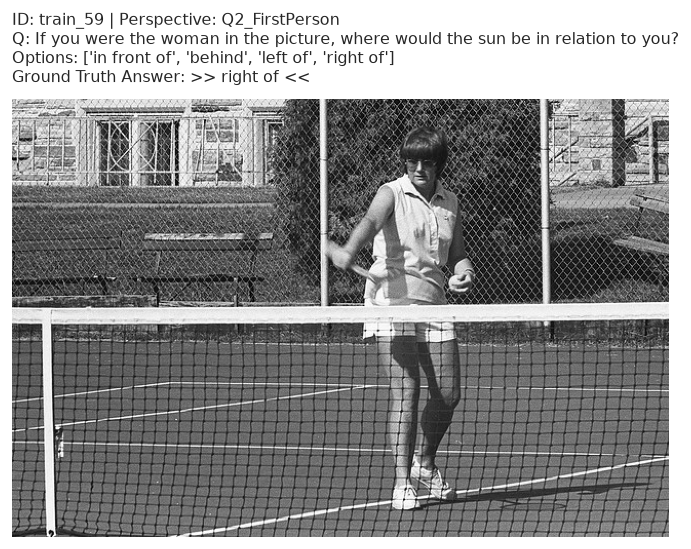

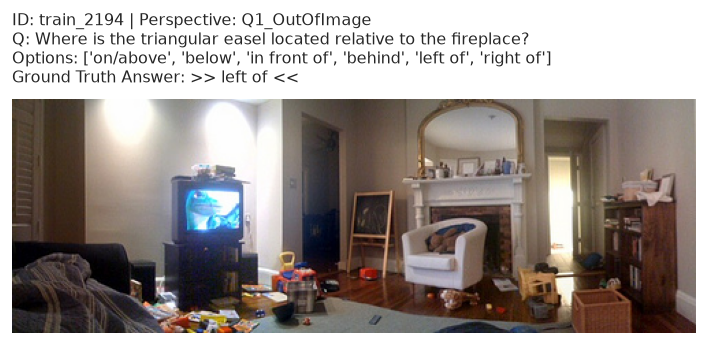

In [11]:
def display_sample(sample_row):
    img_name = sample_row['image']
    img_path = os.path.join(IMAGES_DIR, img_name)
    
    fig, ax = plt.subplots(figsize=(6, 4.5))
    if os.path.exists(img_path):
        img = Image.open(img_path)
        ax.imshow(img)
        ax.axis('off')
    else:
        ax.text(0.5, 0.5, f"Image {img_name}\n(Fetch via HTTP or run download script)",
                ha='center', va='center', fontsize=12, color='gray')
        ax.axis('off')
        
    title_text = (f"ID: {sample_row.get('sample_id', 'N/A')} | Perspective: {sample_row.get('perspective', 'N/A')}\n"
                  f"Q: {sample_row['question']}\n"
                  f"Options: {sample_row['options']}\n"
                  f"Ground Truth Answer: >> {sample_row['answer']} <<")
    plt.title(title_text, fontsize=9.5, loc='left', pad=10)
    plt.tight_layout()
    plt.show()

# Find representative samples from available downloaded images
local_images = set(os.listdir(IMAGES_DIR)) if os.path.exists(IMAGES_DIR) else set()
available_samples = df_all[df_all['image'].isin(local_images)]

print(f"Locally available images for inspection: {len(local_images)}")
if len(available_samples) > 0:
    for idx, row in available_samples.drop_duplicates(subset=['perspective']).head(3).iterrows():
        display_sample(row)
else:
    print("No local images downloaded yet. Showing metadata for 3 samples:")
    for idx, row in df_all.head(3).iterrows():
        print(f"\nQ: {row['question']}\nOptions: {row['options']}\nAnswer: {row['answer']}")


---
## 8. Key Takeaways & Research Directions for Spatial Reasoning

### 1. The Core Performance Bottlenecks in MLLMs:
- **Depth Estimation (Y-axis):** Inferring `in front of` vs `behind` requires understanding camera projection, perspective distortion, and 3D bounding geometry from a 2D image.
- **Egocentric Perspective Transformation (First-Person):** Over 52% of SpatialMQA questions require the model to perform mental rotation into the shoes of an entity in the image, swapping left/right and front/behind.
- **Invisible / Contextual Grounding:** Models cannot rely on trivial object detectors; they must reason about implicit spatial references (e.g. sun direction, ground elevation, room orientation).

### 2. Experimental Benchmark Summary from Paper (ACL 2025):
| Model | Type | Settings | Overall Acc (%) | Q1 (Out-I) | Q2 (1st-p) | Q3 (3rd-p) | X-axis (Acc) | Y-axis (Acc) | Z-axis (Acc) |
|---|---|---|---|---|---|---|---|---|---|
| **Human** | Baseline | - | **98.40** | 98.51 | 98.24 | 100.0 | 98.61 | 97.79 | 98.68 |
| **Random Choice** | Baseline | - | 28.50 | 30.00 | 24.80 | 26.47 | 25.42 | 27.50 | 31.00 |
| **GPT-4o** | Closed MLLM | 0-shot | 40.20 | 44.09 | 33.74 | 61.76 | 37.08 | 47.50 | 36.00 |
| **Gemini-1.5-Flash** | Closed MLLM | 3-shot | 41.73 | 48.18 | 26.83 | 52.94 | 49.58 | 21.88 | 36.00 |
| **LLaVA-1.5 (7B)** | Open MLLM | LoRA | 46.56 | 53.14 | 40.99 | 64.71 | 55.71 | 29.64 | 48.13 |
| **SpaceLLaVA** | Open MLLM | LoRA | **48.14** | 54.87 | 42.37 | 58.82 | 56.00 | 51.85 | 31.41 |

### 3. Next Steps for our Repository:
1. **Dataloader & Prompt Engine:** Build standardized prompt templates matching the paper's exact evaluation format for zero-shot and few-shot inference.
2. **Evaluation Framework:** Implement the paper's official metrics (`calculate_prf1`, `calculate_xyz`, `calculate_result_rule`).
3. **Model Integration:** Support modern MLLMs (e.g. Qwen2-VL, InternVL2, LLaVA-NeXT, GPT-4o / Claude / Gemini APIs).
4. **Novel Method Development:** Develop spatial knowledge representation / spatial prompt chain-of-thought to beat the 48.14% baseline.
